<a href="https://colab.research.google.com/github/nandarosma/why-customers-leave-ml/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [4]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [6]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [7]:
df = df.dropna()

In [8]:
df = df.drop('customerID', axis=1)

In [9]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index')

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887228,0.112772
Two year,0.971513,0.028487


In [10]:
df.groupby('Churn')['tenure'].mean()

,tenure
Churn,
No,37.650010
Yes,17.979133


In [11]:
df.groupby('Churn')['MonthlyCharges'].mean()

,MonthlyCharges
Churn,
No,61.307408
Yes,74.441332


In [12]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [13]:
df.duplicated().sum()

np.int64(22)

In [14]:
df = df.drop_duplicates()

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df[df.duplicated()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [18]:
df[df.duplicated()].shape

(0, 20)

In [19]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 7010 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7010 non-null   object 
 1   SeniorCitizen     7010 non-null   int64  
 2   Partner           7010 non-null   object 
 3   Dependents        7010 non-null   object 
 4   tenure            7010 non-null   int64  
 5   PhoneService      7010 non-null   object 
 6   MultipleLines     7010 non-null   object 
 7   InternetService   7010 non-null   object 
 8   OnlineSecurity    7010 non-null   object 
 9   OnlineBackup      7010 non-null   object 
 10  DeviceProtection  7010 non-null   object 
 11  TechSupport       7010 non-null   object 
 12  StreamingTV       7010 non-null   object 
 13  StreamingMovies   7010 non-null   object 
 14  Contract          7010 non-null   object 
 15  PaperlessBilling  7010 non-null   object 
 16  PaymentMethod     7010 non-null   object 
 17  

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7010.000000,7010.000000,7010.000000,7010.000000
mean,0.162767,32.520399,64.888666,2290.353388
std,0.369180,24.520441,30.064769,2266.820832
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.750000,408.312500
50%,0.000000,29.000000,70.400000,1403.875000
75%,0.000000,56.000000,89.900000,3807.837500
max,1.000000,72.000000,118.750000,8684.800000


In [20]:
df['Churn'].value_counts(normalize=True)

,proportion
Churn,
No,0.735093
Yes,0.264907


In [21]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index')

Churn,No,Yes
Contract,,
Month-to-month,0.573579,0.426421
One year,0.887228,0.112772
Two year,0.971513,0.028487


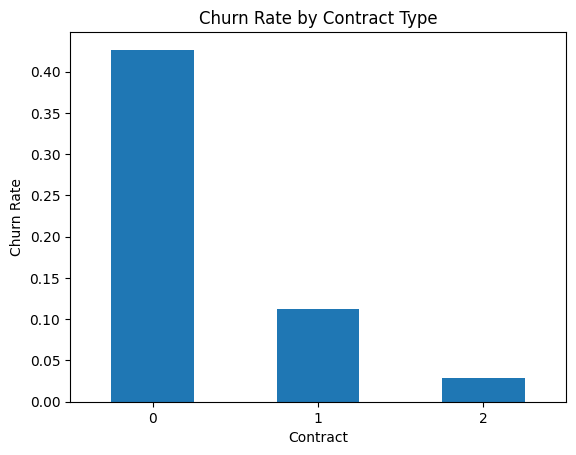

In [31]:
import matplotlib.pyplot as plt

(df.groupby('Contract')['Churn']
   .mean()
   .sort_values(ascending=False)
   .plot(kind='bar'))

plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate')
plt.xlabel('Contract')
plt.xticks(rotation=0)
plt.show()

In [22]:
df.groupby('Churn')['tenure'].mean()

,tenure
Churn,
No,37.721133
Yes,18.088853


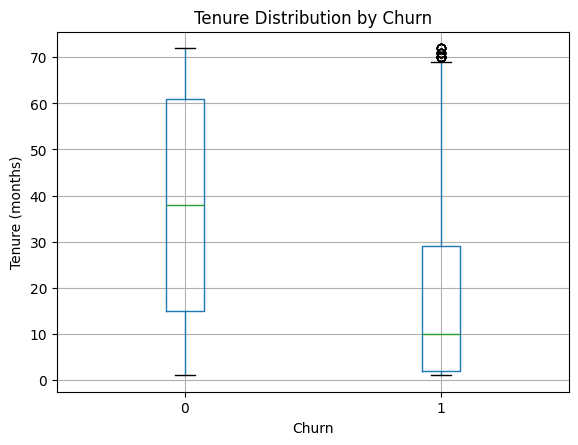

In [32]:
df.boxplot(column='tenure', by='Churn')
plt.title('Tenure Distribution by Churn')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Tenure (months)')
plt.show()

In [23]:
df.groupby('Churn')['MonthlyCharges'].mean()

,MonthlyCharges
Churn,
No,61.387415
Yes,74.604308


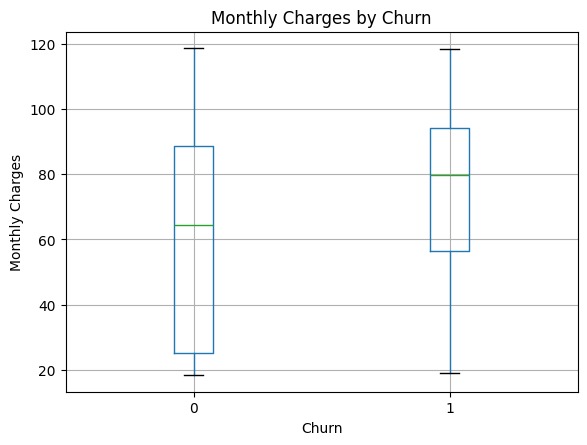

In [33]:
df.boxplot(column='MonthlyCharges', by='Churn')
plt.title('Monthly Charges by Churn')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

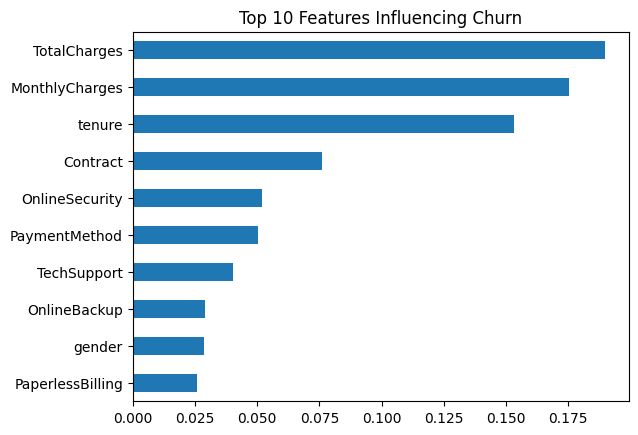

In [35]:
import pandas as pd

importance = rf.feature_importances_
features = X.columns

(pd.Series(importance, index=features)
   .sort_values(ascending=True)
   .tail(10)
   .plot(kind='barh'))

plt.title('Top 10 Features Influencing Churn')
plt.show()

In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [25]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [29]:
from sklearn.svm import SVC

svm = SVC(kernel='linear')
svm.fit(X_train_scaled, y_train)

SVC(kernel='linear')

In [30]:
from sklearn.metrics import classification_report

print("Logistic Regression")
print(classification_report(y_test, lr.predict(X_test_scaled)))

print("Random Forest")
print(classification_report(y_test, rf.predict(X_test)))

print("SVM")
print(classification_report(y_test, svm.predict(X_test_scaled)))

Logistic Regression
              precision    recall  f1-score   support

           0       0.88      0.89      0.89      1081
           1       0.62      0.57      0.59       321

    accuracy                           0.82      1402
   macro avg       0.75      0.73      0.74      1402
weighted avg       0.82      0.82      0.82      1402

Random Forest
              precision    recall  f1-score   support

           0       0.87      0.89      0.88      1081
           1       0.60      0.54      0.57       321

    accuracy                           0.81      1402
   macro avg       0.74      0.72      0.72      1402
weighted avg       0.81      0.81      0.81      1402

SVM
              precision    recall  f1-score   support

           0       0.87      0.91      0.89      1081
           1       0.64      0.56      0.60       321

    accuracy                           0.83      1402
   macro avg       0.76      0.73      0.74      1402
weighted avg       0.82      0.83   

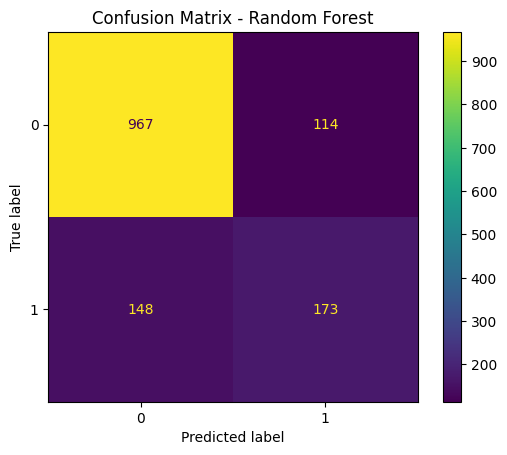

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.title('Confusion Matrix - Random Forest')
plt.show()

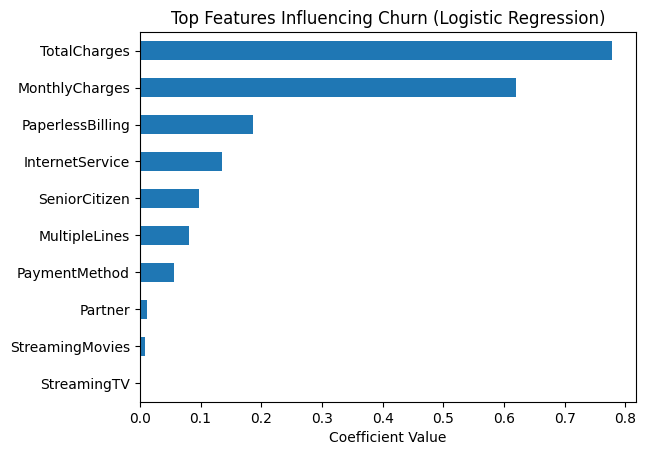

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# ambil koefisien
coef_lr = lr.coef_[0]
features = X.columns

# plot top 10
(pd.Series(coef_lr, index=features)
   .sort_values()
   .tail(10)
   .plot(kind='barh'))

plt.title('Top Features Influencing Churn (Logistic Regression)')
plt.xlabel('Coefficient Value')
plt.show()

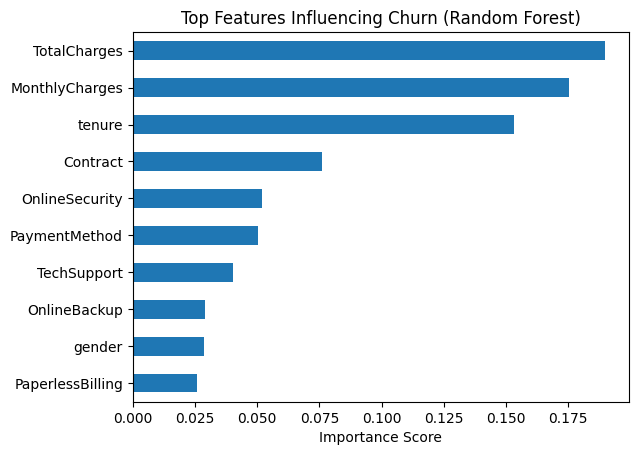

In [39]:
importance = rf.feature_importances_

(pd.Series(importance, index=features)
   .sort_values()
   .tail(10)
   .plot(kind='barh'))

plt.title('Top Features Influencing Churn (Random Forest)')
plt.xlabel('Importance Score')
plt.show()

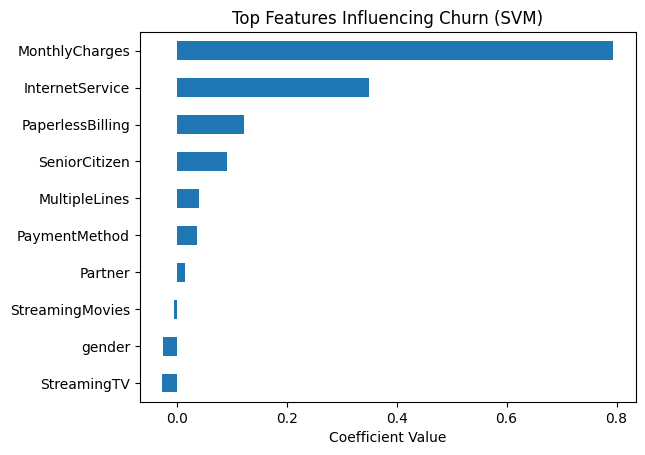

In [41]:
SVC(kernel='linear')
coef_svm = svm.coef_[0]

(pd.Series(coef_svm, index=features)
   .sort_values()
   .tail(10)
   .plot(kind='barh'))

plt.title('Top Features Influencing Churn (SVM)')
plt.xlabel('Coefficient Value')
plt.show()

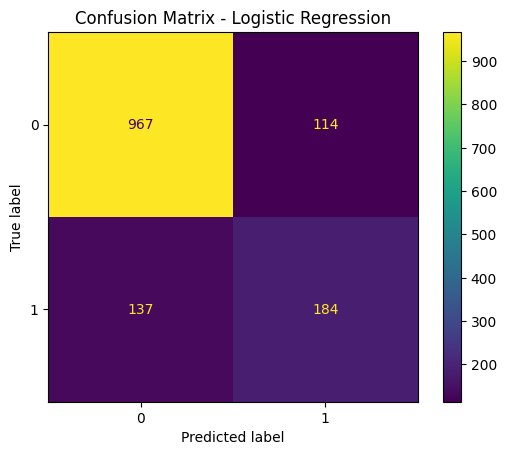

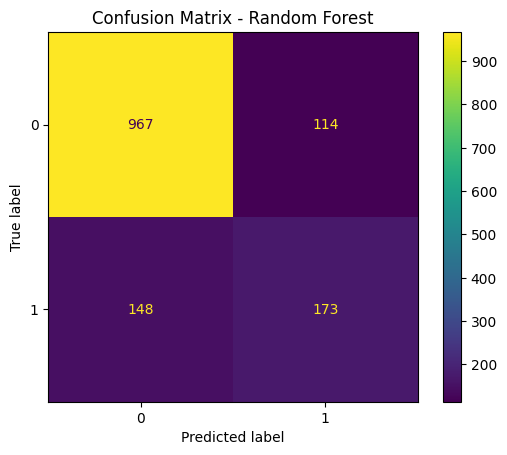

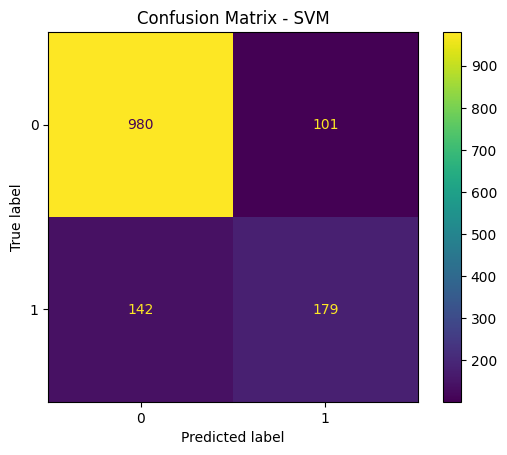

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay

# Logistic
ConfusionMatrixDisplay.from_estimator(lr, X_test_scaled, y_test)
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

# Random Forest
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.title('Confusion Matrix - Random Forest')
plt.show()

# SVM
ConfusionMatrixDisplay.from_estimator(svm, X_test_scaled, y_test)
plt.title('Confusion Matrix - SVM')
plt.show()

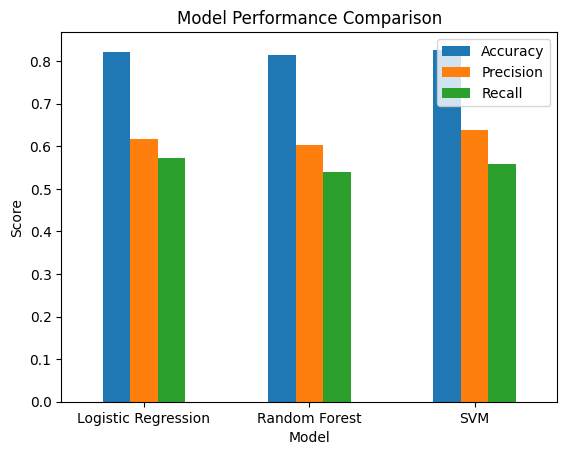

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score

models = ['Logistic Regression', 'Random Forest', 'SVM']

accuracy = [
    accuracy_score(y_test, lr.predict(X_test_scaled)),
    accuracy_score(y_test, rf.predict(X_test)),
    accuracy_score(y_test, svm.predict(X_test_scaled))
]

precision = [
    precision_score(y_test, lr.predict(X_test_scaled)),
    precision_score(y_test, rf.predict(X_test)),
    precision_score(y_test, svm.predict(X_test_scaled))
]

recall = [
    recall_score(y_test, lr.predict(X_test_scaled)),
    recall_score(y_test, rf.predict(X_test)),
    recall_score(y_test, svm.predict(X_test_scaled))
]

df_metrics = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall
})

df_metrics.set_index('Model').plot(kind='bar')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.show()

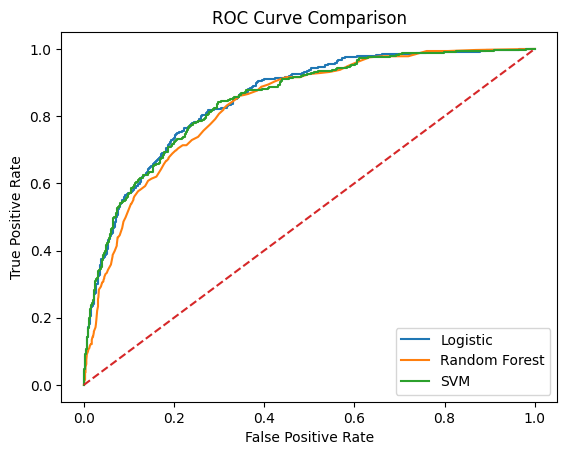

In [45]:
from sklearn.metrics import roc_curve, auc

# Logistic
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

# Random Forest
y_prob_rf = rf.predict_proba(X_test)[:,1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

# SVM (pakai decision function)
y_prob_svm = svm.decision_function(X_test_scaled)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)

plt.plot(fpr_lr, tpr_lr, label='Logistic')
plt.plot(fpr_rf, tpr_rf, label='Random Forest')
plt.plot(fpr_svm, tpr_svm, label='SVM')

plt.plot([0,1], [0,1], linestyle='--')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()